# 1) t-SNE — Projection 2D & Visualisation (City Lifestyle Dataset)



> Dataset : `city_lifestyle_dataset.csv` (300 villes, variables socio‑éco/environnementales).


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


##  Charger les données

In [2]:
# Le notebook essaie d'abord le chemin "data/..." (structure projet classique),
# puis retombe sur le chemin de ce sandbox (/mnt/data) si besoin.

CANDIDATE_PATHS = [
    os.path.join("../data", "city_lifestyle_dataset.csv"),
    "city_lifestyle_dataset.csv",
    os.path.join("/mnt/data", "city_lifestyle_dataset.csv"),
]

DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Impossible de trouver 'city_lifestyle_dataset.csv'. "
        "Place-le dans le dossier 'data/' ou à côté du notebook."
    )

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH, "| shape:", df.shape)
df.head()


Loaded: ../data\city_lifestyle_dataset.csv | shape: (300, 10)


,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


##  Préparer X (features numériques)

In [3]:
# Colonnes non numériques / identifiants à exclure de X
non_feature_cols = [c for c in ["city_name", "country"] if c in df.columns]

# y = région (optionnel, uniquement pour colorer le scatter)
y = df["country"].astype("category").cat.codes.values if "country" in df.columns else None
y_names = df["country"].astype("category").cat.categories.tolist() if "country" in df.columns else None

X = df.drop(columns=non_feature_cols)

# Garder uniquement les colonnes numériques au cas où
X = X.select_dtypes(include=[np.number])

print("Features used:", list(X.columns))
print("X shape:", X.shape, "| y:", ("none" if y is None else f"{len(np.unique(y))} categories"))

# Standardisation (recommandée avant t-SNE)
X_scaled = StandardScaler().fit_transform(X)


Features used: ['population_density', 'avg_income', 'internet_penetration', 'avg_rent', 'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio']
X shape: (300, 8) | y: 6 categories


##  t-SNE : projection 2D

In [4]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=1000,   # ← ici
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)



## Visualisation 2D

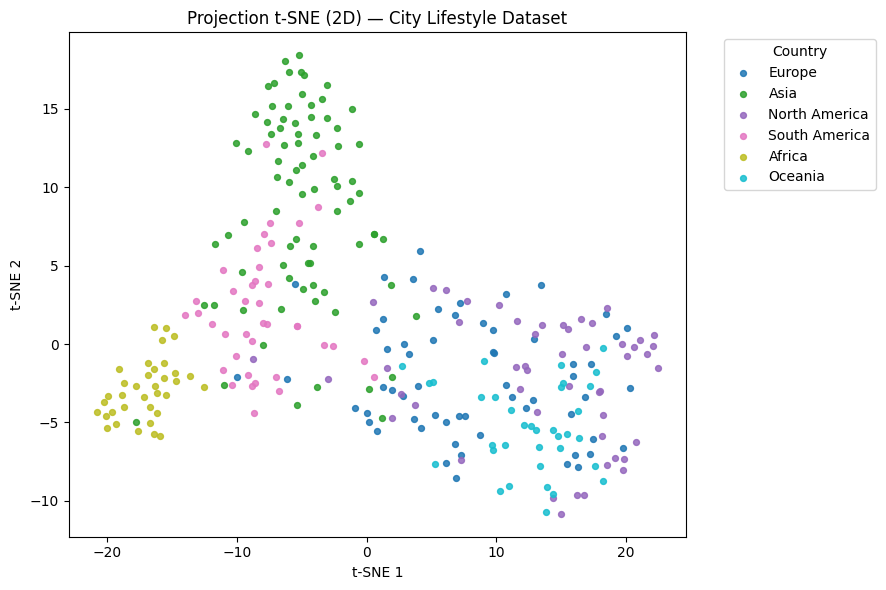

In [11]:
plt.figure(figsize=(9, 6))

countries = df['country'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(countries)))

for country, color in zip(countries, colors):
    mask = df['country'] == country
    
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        label=country,
        alpha=0.85,
        s=18,
        color=color
    )

plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.title("Projection t-SNE (2D) — City Lifestyle Dataset")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## Observation sur la structure obtenue

La projection t-SNE montre plusieurs clusters correspondant aux régions du monde. L’Afrique apparaît clairement isolée, tandis que l’Asie forme un groupe distinct en partie supérieure. En revanche, l’Europe, l’Amérique du Nord et l’Océanie présentent un certain chevauchement, suggérant des profils de style de vie plus similaires.

Globalement, la structure met en évidence une séparation nette pour certaines régions et des proximités pour d’autres.

In [13]:
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Export embeddings 2D (standard format for evaluation)
emb_2d = pd.DataFrame({
    "city_name": df["city_name"],
    "country": df["country"],
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
})

OUTPUT_PATH = os.path.join(OUTPUT_DIR, "tsne_emb_2d.csv")
emb_2d.to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}, shape={emb_2d.shape}")
emb_2d.head(10)

Saved: ../outputs\tsne_emb_2d.csv, shape=(300, 4)


,city_name,country,x,y
0,Old Vista,Europe,11.241733,-3.356271
1,Beachport,Europe,9.782010,0.879463
2,Valleyborough,Europe,17.283047,-1.263758
3,City,Europe,7.303801,-7.058923
4,Falls,Europe,20.082563,1.028656
5,North Falls,Europe,10.784376,-2.597136
6,Hillhaven,Europe,6.136463,-7.558820
7,Gardenton,Europe,9.871101,-0.566015
8,Springsville,Europe,19.790152,-6.631950
9,North Ridge,Europe,5.517734,2.219014
